## Candle Stick

### Load Data

In [1]:
import pandas as pd
import numpy as np
import mplfinance as mpf
from scipy import signal, stats

prices_dir = "../database/historical_data_yf"
stock_code = "TCS"


def load_data(stock):
    file_path = f"{prices_dir}/{stock}.NS_yf.json"
    df = pd.read_json(file_path).T
    
    dates = pd.to_datetime(df.index.tolist()).tolist()
    
    cols = df.columns.tolist()
    cols = [c.replace(f"_{stock}.NS", '').lower() for c in cols]
    df.columns = cols
    return df, dates, cols

df, dates, cols = load_data(stock_code)


In [15]:
import numpy as np
import pandas as pd


def detect_candles_claude(df, **thresholds):
    """
    Improved candlestick pattern detection with confidence scoring.
    
    Improvements:
    - Better context features (volatility, momentum, trend strength)
    - Confidence scores (0-1) for each pattern based on pattern quality
    - Stricter validation rules with adaptive thresholds
    - Additional patterns (Morning/Evening Engulfing, Harami, etc.)
    
    Parameters:
    -----------
    df : pd.DataFrame
        OHLC data with columns ['open', 'high', 'low', 'close']
    **thresholds : dict
        Optional threshold overrides. See THRESHOLD_DEFAULTS below.
    
    Returns:
    --------
    DataFrame with pattern columns + confidence columns
    
    Example usage:
    ---------------
    # Default thresholds
    result = detect_candles_claude(df)
    
    # Custom thresholds
    result = detect_candles_claude(
        df,
        LONG_DAY_THRESHOLD=0.75,
        HAMMER_LOWER_WICK_RATIO=3.0,
        DOJI_THRESHOLD=0.1
    )
    """
    
    # =========================
    # THRESHOLD CONFIGURATION
    # =========================
    THRESHOLD_DEFAULTS = {
        # Single candle: Body ratios
        "LONG_DAY_THRESHOLD": 0.7,
        "SHORT_DAY_THRESHOLD": 0.25,
        
        # Doji variants
        "DOJI_THRESHOLD": 0.08,
        "GRAVESTONE_DOJI_LOWER_WICK": 0.05,
        "GRAVESTONE_DOJI_UPPER_WICK": 0.6,
        "DRAGONFLY_DOJI_LOWER_WICK": 0.6,
        "DRAGONFLY_DOJI_UPPER_WICK": 0.05,
        "LONG_LEGGED_DOJI_UPPER_WICK": 0.4,
        "LONG_LEGGED_DOJI_LOWER_WICK": 0.4,
        
        # Hammer / Hanging Man
        "HAMMER_LOWER_WICK_RATIO": 2.5,  # lower_wick > 2.5 * body
        "HAMMER_UPPER_WICK_RATIO": 0.2,  # upper_wick < 0.2 * body
        "HAMMER_BODY_RATIO": 0.4,
        
        # Shooting Star
        "SHOOTING_STAR_UPPER_WICK_RATIO": 2.5,  # upper_wick > 2.5 * body
        "SHOOTING_STAR_LOWER_WICK_RATIO": 0.2,  # lower_wick < 0.2 * body
        "SHOOTING_STAR_BODY_RATIO": 0.4,
        
        # Engulfing
        "ENGULFING_BODY_MULTIPLIER": 1.1,  # current body > prev body * 1.1
        "ENGULFING_PREV_BODY_THRESHOLD": 0.3,  # prev body < 0.3 for bonus
        
        # Harami
        "HARAMI_BODY_MULTIPLIER": 0.7,  # current body < prev body * 0.7
        "HARAMI_CURRENT_BODY_THRESHOLD": 0.5,
        "HARAMI_PREV_BODY_THRESHOLD": 0.5,
        
        # Piercing Line / Dark Cloud Cover
        "PIERCING_LINE_BODY_RATIO": 0.5,
        "PIERCING_LINE_PENETRATION_MAX": 0.5,  # Max penetration ratio
        
        # Morning/Evening Star
        "MORNING_STAR_PREV_BODY_RATIO": 0.3,  # doji-like
        "MORNING_STAR_PREV2_BODY_RATIO": 0.5,  # strong bearish
    }
    
    # Merge user-provided thresholds with defaults
    config = {**THRESHOLD_DEFAULTS, **thresholds}
    
    df = df.copy()
    
    # =========================
    # CANDLE ANATOMY
    # =========================
    df["body"] = (df["close"] - df["open"]).abs()
    df["range"] = (df["high"] - df["low"]).replace(0, 1e-9)
    
    df["upper_wick"] = df["high"] - df[["open", "close"]].max(axis=1)
    df["lower_wick"] = df[["open", "close"]].min(axis=1) - df["low"]
    
    df["body_ratio"] = df["body"] / df["range"]
    df["upper_wick_ratio"] = df["upper_wick"] / df["range"]
    df["lower_wick_ratio"] = df["lower_wick"] / df["range"]
    
    df["is_bullish"] = df["close"] > df["open"]
    df["is_bearish"] = df["close"] < df["open"]
    
    prev = df.shift(1)
    prev2 = df.shift(2)
    
    # =========================
    # IMPROVED CONTEXT FEATURES
    # =========================
    
    # Trend (EMA + slope)
    df["ema20"] = df["close"].ewm(span=20).mean()
    df["ema_slope"] = df["ema20"].diff()
    
    # Trend strength (normalized slope)
    atr14 = df["range"].rolling(14).mean()
    df["ema_slope_normalized"] = df["ema_slope"] / atr14
    
    df["uptrend"] = (df["close"] > df["ema20"]) & (df["ema_slope"] > 0)
    df["downtrend"] = (df["close"] < df["ema20"]) & (df["ema_slope"] < 0)
    
    # Volatility (ATR-based, normalized)
    df["atr14"] = atr14
    df["volatility"] = df["atr14"] / df["close"] * 100  # % volatility
    
    # Support / Resistance (dynamic zones)
    window = 20
    df["recent_low"] = df["low"].rolling(window).min()
    df["recent_high"] = df["high"].rolling(window).max()
    df["recent_mid"] = (df["recent_low"] + df["recent_high"]) / 2
    
    # Distance to zones (as % of range)
    recent_range = df["recent_high"] - df["recent_low"]
    df["dist_to_support"] = (df["close"] - df["recent_low"]) / recent_range * 100
    df["dist_to_resistance"] = (df["recent_high"] - df["close"]) / recent_range * 100
    
    df["near_support"] = df["dist_to_support"] < 10  # Bottom 10% of range
    df["near_resistance"] = df["dist_to_resistance"] < 10  # Top 10% of range
    
    # Momentum (RSI-inspired, normalized price change)
    df["momentum"] = df["close"].diff() / df["atr14"]
    df["momentum_ma"] = df["momentum"].rolling(5).mean()
    
    # =========================
    # HELPER FUNCTION: Confidence Scorer
    # =========================
    def confidence_score(*conditions):
        """
        Combine multiple boolean conditions into a confidence score (0-1).
        Each True condition adds equal weight.
        """
        valid_conditions = [c for c in conditions if c is not None]
        if not valid_conditions:
            return 0.0
        score = sum(valid_conditions) / len(valid_conditions)
        return float(score)
    
    # =========================
    # SINGLE CANDLE PATTERNS
    # =========================
    
    # Long Day (strong body)
    df["long_day"] = df["body_ratio"] > config["LONG_DAY_THRESHOLD"]
    df["long_day_conf"] = 0.0
    mask = df["long_day"]
    df.loc[mask, "long_day_conf"] = (
        (df.loc[mask, "body_ratio"] - config["LONG_DAY_THRESHOLD"]) / (1 - config["LONG_DAY_THRESHOLD"])
    ).clip(0, 1)
    
    # Short Day / Doji variants
    df["short_day"] = df["body_ratio"] < config["SHORT_DAY_THRESHOLD"]
    df["short_day_conf"] = 0.0
    mask = df["short_day"]
    df.loc[mask, "short_day_conf"] = 1 - df.loc[mask, "body_ratio"] / config["SHORT_DAY_THRESHOLD"]

    # Doji (very small body, balanced wicks)
    df["doji"] = df["body_ratio"] < config["DOJI_THRESHOLD"]
    df["doji_conf"] = 0.0
    mask = df["doji"]
    wick_balance = (
        1 - np.abs(df.loc[mask, "upper_wick_ratio"] - df.loc[mask, "lower_wick_ratio"])
    )
    df.loc[mask, "doji_conf"] = (
        (1 - df.loc[mask, "body_ratio"] / config["DOJI_THRESHOLD"]) * 0.6 +  # 60% = body smallness
        wick_balance * 0.4  # 40% = wick balance
    ).clip(0, 1)
    
    # Gravestone Doji (small body, no lower wick, big upper wick)
    df["gravestone_doji"] = (
        (df["body_ratio"] < config["DOJI_THRESHOLD"]) &
        (df["lower_wick_ratio"] < config["GRAVESTONE_DOJI_LOWER_WICK"]) &
        (df["upper_wick_ratio"] > config["GRAVESTONE_DOJI_UPPER_WICK"])
    )
    df["gravestone_doji_conf"] = 0.0
    mask = df["gravestone_doji"]
    df.loc[mask, "gravestone_doji_conf"] = (
        (1 - df.loc[mask, "body_ratio"] / config["DOJI_THRESHOLD"]) * 0.3 +
        (1 - df.loc[mask, "lower_wick_ratio"] / config["GRAVESTONE_DOJI_LOWER_WICK"]) * 0.3 +
        (df.loc[mask, "upper_wick_ratio"] - config["GRAVESTONE_DOJI_UPPER_WICK"]) / 0.4 * 0.4
    ).clip(0, 1)
    
    # Dragonfly Doji (small body, no upper wick, big lower wick)
    df["dragonfly_doji"] = (
        (df["body_ratio"] < config["DOJI_THRESHOLD"]) &
        (df["upper_wick_ratio"] < config["DRAGONFLY_DOJI_UPPER_WICK"]) &
        (df["lower_wick_ratio"] > config["DRAGONFLY_DOJI_LOWER_WICK"])
    )
    df["dragonfly_doji_conf"] = 0.0
    mask = df["dragonfly_doji"]
    df.loc[mask, "dragonfly_doji_conf"] = (
        (1 - df.loc[mask, "body_ratio"] / config["DOJI_THRESHOLD"]) * 0.3 +
        (1 - df.loc[mask, "upper_wick_ratio"] / config["DRAGONFLY_DOJI_UPPER_WICK"]) * 0.3 +
        (df.loc[mask, "lower_wick_ratio"] - config["DRAGONFLY_DOJI_LOWER_WICK"]) / 0.4 * 0.4
    ).clip(0, 1)
    
    # Long Legged Doji
    df["long_legged_doji"] = (
        (df["body_ratio"] < config["DOJI_THRESHOLD"]) &
        (df["upper_wick_ratio"] > config["LONG_LEGGED_DOJI_UPPER_WICK"]) &
        (df["lower_wick_ratio"] > config["LONG_LEGGED_DOJI_LOWER_WICK"])
    )
    df["long_legged_doji_conf"] = 0.0
    mask = df["long_legged_doji"]
    wick_balance = 1 - np.abs(df.loc[mask, "upper_wick_ratio"] - df.loc[mask, "lower_wick_ratio"]) / 0.8
    df.loc[mask, "long_legged_doji_conf"] = (
        (1 - df.loc[mask, "body_ratio"] / config["DOJI_THRESHOLD"]) * 0.4 +
        wick_balance * 0.6
    ).clip(0, 1)
    
    # Hammer (strong reversal at support)
    df["hammer"] = (
        (df["lower_wick"] > config["HAMMER_LOWER_WICK_RATIO"] * df["body"]) &
        (df["upper_wick"] < config["HAMMER_UPPER_WICK_RATIO"] * df["body"]) &
        (df["body_ratio"] < config["HAMMER_BODY_RATIO"])
    )
    df["hammer_conf"] = 0.0
    mask = df["hammer"]
    wick_ratio = df.loc[mask, "lower_wick"] / df.loc[mask, "body"].clip(lower=0.01)
    df.loc[mask, "hammer_conf"] = (
        (wick_ratio.clip(upper=5) / 5) * 0.5 +
        (1 - df.loc[mask, "upper_wick_ratio"] / config["HAMMER_UPPER_WICK_RATIO"]) * 0.25 +
        (1 - df.loc[mask, "body_ratio"] / config["HAMMER_BODY_RATIO"]) * 0.25
    ).clip(0, 1)
    
    # Hammer validation (context matters)
    df["hammer_valid"] = False
    df["hammer_valid_conf"] = 0.0
    mask = df["hammer"]
    df.loc[mask, "hammer_valid"] = (
        df.loc[mask, "downtrend"] &
        df.loc[mask, "near_support"]
    )
    df.loc[mask, "hammer_valid_conf"] = (
        df.loc[mask, "hammer_conf"] * 0.5 +
        df.loc[mask, "downtrend"].astype(float) * 0.25 +
        df.loc[mask, "near_support"].astype(float) * 0.25
    ).clip(0, 1)
    
    # Hanging Man (same shape as hammer, opposite context)
    df["hanging_man"] = df["hammer"]
    df["hanging_man_conf"] = df["hammer_conf"]
    
    df["hanging_man_valid"] = False
    df["hanging_man_valid_conf"] = 0.0
    mask = df["hanging_man"]
    df.loc[mask, "hanging_man_valid"] = (
        df.loc[mask, "uptrend"] &
        df.loc[mask, "near_resistance"]
    )
    df.loc[mask, "hanging_man_valid_conf"] = (
        df.loc[mask, "hanging_man_conf"] * 0.5 +
        df.loc[mask, "uptrend"].astype(float) * 0.25 +
        df.loc[mask, "near_resistance"].astype(float) * 0.25
    ).clip(0, 1)
    
    # Shooting Star (opposite of hammer: big upper wick)
    df["shooting_star"] = (
        (df["upper_wick"] > config["SHOOTING_STAR_UPPER_WICK_RATIO"] * df["body"]) &
        (df["lower_wick"] < config["SHOOTING_STAR_LOWER_WICK_RATIO"] * df["body"]) &
        (df["body_ratio"] < config["SHOOTING_STAR_BODY_RATIO"])
    )
    df["shooting_star_conf"] = 0.0
    mask = df["shooting_star"]
    wick_ratio = df.loc[mask, "upper_wick"] / df.loc[mask, "body"].clip(lower=0.01)
    df.loc[mask, "shooting_star_conf"] = (
        (wick_ratio.clip(upper=5) / 5) * 0.5 +
        (1 - df.loc[mask, "lower_wick_ratio"] / config["SHOOTING_STAR_LOWER_WICK_RATIO"]) * 0.25 +
        (1 - df.loc[mask, "body_ratio"] / config["SHOOTING_STAR_BODY_RATIO"]) * 0.25
    ).clip(0, 1)
    
    df["shooting_star_valid"] = False
    df["shooting_star_valid_conf"] = 0.0
    mask = df["shooting_star"]
    df.loc[mask, "shooting_star_valid"] = (
        df.loc[mask, "uptrend"] &
        df.loc[mask, "near_resistance"]
    )
    df.loc[mask, "shooting_star_valid_conf"] = (
        df.loc[mask, "shooting_star_conf"] * 0.5 +
        df.loc[mask, "uptrend"].astype(float) * 0.25 +
        df.loc[mask, "near_resistance"].astype(float) * 0.25
    ).clip(0, 1)
    
    # =========================
    # DOUBLE CANDLE PATTERNS
    # =========================
    
    # Bullish Engulfing
    df["bullish_engulfing"] = (
        (prev["close"] < prev["open"]) &  # Previous bearish
        (df["close"] > df["open"]) &  # Current bullish
        (df["open"] <= prev["close"]) &  # Opens at/below prev close
        (df["close"] >= prev["open"]) &  # Closes above prev open
        (df["body"] > prev["body"] * config["ENGULFING_BODY_MULTIPLIER"])  # Larger body
    )
    df["bullish_engulfing_conf"] = 0.0
    mask = df["bullish_engulfing"]
    engulf_ratio = df.loc[mask, "body"] / (prev.loc[mask, "body"] + 1e-9)
    df.loc[mask, "bullish_engulfing_conf"] = (
        (engulf_ratio.clip(upper=3) / 3) * 0.5 +
        (df.loc[mask, "body_ratio"] / 0.8).clip(0, 1) * 0.3 +
        ((prev.loc[mask, "body_ratio"] < config["ENGULFING_PREV_BODY_THRESHOLD"]).astype(float)) * 0.2
    ).clip(0, 1)
    
    df["bullish_engulfing_valid"] = False
    df["bullish_engulfing_valid_conf"] = 0.0
    mask = df["bullish_engulfing"]
    df.loc[mask, "bullish_engulfing_valid"] = (
        df.loc[mask, "downtrend"]
    )
    df.loc[mask, "bullish_engulfing_valid_conf"] = (
        df.loc[mask, "bullish_engulfing_conf"] * 0.7 +
        df.loc[mask, "downtrend"].astype(float) * 0.3
    ).clip(0, 1)
    
    # Bearish Engulfing
    df["bearish_engulfing"] = (
        (prev["close"] > prev["open"]) &
        (df["close"] < df["open"]) &
        (df["open"] >= prev["close"]) &
        (df["close"] <= prev["open"]) &
        (df["body"] > prev["body"] * config["ENGULFING_BODY_MULTIPLIER"])
    )
    df["bearish_engulfing_conf"] = 0.0
    mask = df["bearish_engulfing"]
    engulf_ratio = df.loc[mask, "body"] / (prev.loc[mask, "body"] + 1e-9)
    df.loc[mask, "bearish_engulfing_conf"] = (
        (engulf_ratio.clip(upper=3) / 3) * 0.5 +
        (df.loc[mask, "body_ratio"] / 0.8).clip(0, 1) * 0.3 +
        ((prev.loc[mask, "body_ratio"] < config["ENGULFING_PREV_BODY_THRESHOLD"]).astype(float)) * 0.2
    ).clip(0, 1)
    
    df["bearish_engulfing_valid"] = False
    df["bearish_engulfing_valid_conf"] = 0.0
    mask = df["bearish_engulfing"]
    df.loc[mask, "bearish_engulfing_valid"] = (
        df.loc[mask, "uptrend"]
    )
    df.loc[mask, "bearish_engulfing_valid_conf"] = (
        df.loc[mask, "bearish_engulfing_conf"] * 0.7 +
        df.loc[mask, "uptrend"].astype(float) * 0.3
    ).clip(0, 1)
    
    # Harami (opposite of engulfing: smaller body inside previous)
    df["bullish_harami"] = (
        (prev["close"] < prev["open"]) &  # Previous bearish
        (df["close"] > df["open"]) &  # Current bullish
        (df["open"] > prev["close"]) &  # Opens above prev close
        (df["close"] < prev["open"]) &  # Closes below prev open
        (df["body"] < prev["body"] * config["HARAMI_BODY_MULTIPLIER"])  # Smaller body
    )
    df["bullish_harami_conf"] = 0.0
    mask = df["bullish_harami"]
    harami_ratio = (prev.loc[mask, "body"] - df.loc[mask, "body"]) / (prev.loc[mask, "body"] + 1e-9)
    df.loc[mask, "bullish_harami_conf"] = (
        (harami_ratio.clip(0, 1)) * 0.5 +
        (df.loc[mask, "body_ratio"] / config["HARAMI_CURRENT_BODY_THRESHOLD"]).clip(0, 1) * 0.3 +
        ((prev.loc[mask, "body_ratio"] > config["HARAMI_PREV_BODY_THRESHOLD"]).astype(float)) * 0.2
    ).clip(0, 1)
    
    # Piercing Line (bullish, gap down then strong recovery)
    df["piercing_line"] = (
        (prev["close"] < prev["open"]) &  # Bearish candle
        (df["close"] > df["open"]) &  # Bullish candle
        (df["open"] < prev["low"]) &  # Opens below prev low (gap)
        (df["close"] > (prev["open"] + prev["close"]) / 2) &  # Closes above midpoint
        (df["close"] <= prev["open"]) &  # But below prev open
        (df["body_ratio"] > config["PIERCING_LINE_BODY_RATIO"])  # Good body
    )
    df["piercing_line_conf"] = 0.0
    mask = df["piercing_line"]
    penetration = (df.loc[mask, "close"] - (prev.loc[mask, "open"] + prev.loc[mask, "close"]) / 2) / (
        (prev.loc[mask, "open"] - prev.loc[mask, "close"]).abs() + 1e-9
    )
    df.loc[mask, "piercing_line_conf"] = (
        (penetration.clip(0, config["PIERCING_LINE_PENETRATION_MAX"]) / config["PIERCING_LINE_PENETRATION_MAX"]) * 0.5 +
        (df.loc[mask, "body_ratio"] / 0.8).clip(0, 1) * 0.5
    ).clip(0, 1)
    
    # Dark Cloud Cover (bearish version of piercing line)
    df["dark_cloud_cover"] = (
        (prev["close"] > prev["open"]) &
        (df["close"] < df["open"]) &
        (df["open"] > prev["high"]) &
        (df["close"] < (prev["open"] + prev["close"]) / 2) &
        (df["close"] >= prev["open"]) &
        (df["body_ratio"] > config["PIERCING_LINE_BODY_RATIO"])
    )
    df["dark_cloud_cover_conf"] = 0.0
    mask = df["dark_cloud_cover"]
    penetration = ((prev.loc[mask, "open"] + prev.loc[mask, "close"]) / 2 - df.loc[mask, "close"]) / (
        (prev.loc[mask, "close"] - prev.loc[mask, "open"]).abs() + 1e-9
    )
    df.loc[mask, "dark_cloud_cover_conf"] = (
        (penetration.clip(0, config["PIERCING_LINE_PENETRATION_MAX"]) / config["PIERCING_LINE_PENETRATION_MAX"]) * 0.5 +
        (df.loc[mask, "body_ratio"] / 0.8).clip(0, 1) * 0.5
    ).clip(0, 1)
    
    # =========================
    # TRIPLE CANDLE PATTERNS
    # =========================
    
    # Morning Star (bullish reversal: down, doji-like, up)
    df["morning_star"] = (
        (prev2["close"] < prev2["open"]) &  # Strong bearish
        (prev["body_ratio"] < config["MORNING_STAR_PREV_BODY_RATIO"]) &  # Small body (doji-like)
        (prev["low"] < prev2["low"]) &  # Continues down
        (df["close"] > df["open"]) &  # Reverses up
        (df["close"] > (prev2["open"] + prev2["close"]) / 2)  # Strong recovery
    )
    df["morning_star_conf"] = 0.0
    mask = df["morning_star"]
    recovery = (df.loc[mask, "close"] - (prev2.loc[mask, "open"] + prev2.loc[mask, "close"]) / 2) / (
        (prev2.loc[mask, "open"] - prev2.loc[mask, "close"]).abs() + 1e-9
    )
    df.loc[mask, "morning_star_conf"] = (
        ((prev2.loc[mask, "body_ratio"] > config["MORNING_STAR_PREV2_BODY_RATIO"]).astype(float)) * 0.3 +
        ((prev.loc[mask, "body_ratio"] < config["MORNING_STAR_PREV_BODY_RATIO"]).astype(float)) * 0.3 +
        (recovery.clip(0, 1)) * 0.4
    ).clip(0, 1)
    
    df["morning_star_valid"] = df["morning_star"] & df["downtrend"]
    df["morning_star_valid_conf"] = (
        df["morning_star_conf"] * 0.7 +
        df["downtrend"].astype(float) * 0.3
    ).clip(0, 1)
    
    # Evening Star (bearish version)
    df["evening_star"] = (
        (prev2["close"] > prev2["open"]) &
        (prev["body_ratio"] < config["MORNING_STAR_PREV_BODY_RATIO"]) &
        (prev["high"] > prev2["high"]) &
        (df["close"] < df["open"]) &
        (df["close"] < (prev2["open"] + prev2["close"]) / 2)
    )
    df["evening_star_conf"] = 0.0
    mask = df["evening_star"]
    decline = ((prev2.loc[mask, "open"] + prev2.loc[mask, "close"]) / 2 - df.loc[mask, "close"]) / (
        (prev2.loc[mask, "close"] - prev2.loc[mask, "open"]).abs() + 1e-9
    )
    df.loc[mask, "evening_star_conf"] = (
        ((prev2.loc[mask, "body_ratio"] > config["MORNING_STAR_PREV2_BODY_RATIO"]).astype(float)) * 0.3 +
        ((prev.loc[mask, "body_ratio"] < config["MORNING_STAR_PREV_BODY_RATIO"]).astype(float)) * 0.3 +
        (decline.clip(0, 1)) * 0.4
    ).clip(0, 1)
    
    df["evening_star_valid"] = df["evening_star"] & df["uptrend"]
    df["evening_star_valid_conf"] = (
        df["evening_star_conf"] * 0.7 +
        df["uptrend"].astype(float) * 0.3
    ).clip(0, 1)
    
    return df

In [35]:
def plot_valid_signals_(df, conf_threshold=0.5):
    df_plot = df.copy()

    df_plot = df_plot.rename(columns={
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close"
    })

    df_plot.index = pd.to_datetime(df_plot.index)

    # Reduce clutter
    df_plot = df_plot.tail(120)
    df = df.tail(120).reset_index(drop=True)

    bullish_markers = np.full(len(df), np.nan)
    bearish_markers = np.full(len(df), np.nan)

    # Store annotation info: (index, y_pos, text, color, conf_score)
    annotations = []

    for i, row in df.iterrows():

        # 🟢 Bullish
        if row.get("hammer_valid", False):
            conf = row.get("hammer_valid_conf", 0.0)
            if conf >= conf_threshold:
                bullish_markers[i] = row["low"] * 0.995
                annotations.append((i, row["low"], "Hammer", "green", conf))

        elif row.get("bullish_engulfing_valid", False):
            conf = row.get("bullish_engulfing_valid_conf", 0.0)
            if conf >= conf_threshold:
                bullish_markers[i] = row["low"] * 0.995
                annotations.append((i, row["low"], "BullEng", "green", conf))

        elif row.get("morning_star_valid", False):
            conf = row.get("morning_star_valid_conf", 0.0)
            if conf >= conf_threshold:
                bullish_markers[i] = row["low"] * 0.995
                annotations.append((i, row["low"], "Morning★", "green", conf))

        elif row.get("piercing_line", False):
            conf = row.get("piercing_line_conf", 0.0)
            if conf >= conf_threshold:
                bullish_markers[i] = row["low"] * 0.995
                annotations.append((i, row["low"], "Piercing", "green", conf))

        # 🔴 Bearish
        elif row.get("hanging_man_valid", False):
            conf = row.get("hanging_man_valid_conf", 0.0)
            if conf >= conf_threshold:
                bearish_markers[i] = row["high"] * 1.005
                annotations.append((i, row["high"], "HangMan", "red", conf))

        elif row.get("shooting_star_valid", False):
            conf = row.get("shooting_star_valid_conf", 0.0)
            if conf >= conf_threshold:
                bearish_markers[i] = row["high"] * 1.005
                annotations.append((i, row["high"], "Shoot★", "red", conf))

        elif row.get("bearish_engulfing_valid", False):
            conf = row.get("bearish_engulfing_valid_conf", 0.0)
            if conf >= conf_threshold:
                bearish_markers[i] = row["high"] * 1.005
                annotations.append((i, row["high"], "BearEng", "red", conf))

        elif row.get("evening_star_valid", False):
            conf = row.get("evening_star_valid_conf", 0.0)
            if conf >= conf_threshold:
                bearish_markers[i] = row["high"] * 1.005
                annotations.append((i, row["high"], "Evening★", "red", conf))

        elif row.get("dark_cloud_cover", False):
            conf = row.get("dark_cloud_cover_conf", 0.0)
            if conf >= conf_threshold:
                bearish_markers[i] = row["high"] * 1.005
                annotations.append((i, row["high"], "DarkCloud", "red", conf))

    apds = []

    if not np.isnan(bullish_markers).all():
        apds.append(
            mpf.make_addplot(
                bullish_markers,
                type='scatter',
                marker='^',
                markersize=80,
                color='green'
            )
        )

    if not np.isnan(bearish_markers).all():
        apds.append(
            mpf.make_addplot(
                bearish_markers,
                type='scatter',
                marker='v',
                markersize=80,
                color='red'
            )
        )

    fig, axlist = mpf.plot(
        df_plot,
        type="candle",
        style="charles",
        addplot=apds,
        figsize=(14, 7),
        returnfig=True
    )

    ax = axlist[0]

    # --- Add text annotations with confidence ---
    y_offset = (df["high"].max() - df["low"].min()) * 0.13

    for x, y, text, color, conf in annotations:
        # Format: "PatternName\n(0.85)" where 0.85 is confidence
        label = f"{text}\n({conf:.2f})"
        
        if color == "green":
            y_text = y - y_offset
        else:
            y_text = y + y_offset

        ax.text(
            x,
            y_text,
            label,
            color=color,
            fontsize=7,
            ha="center",
            va="center",
            weight='bold',
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor='white',
                edgecolor=color,
                alpha=0.6,
                linewidth=1
            )
        )

    return fig

# Trial with Strong Candle Patterns

In [62]:
import pandas as pd
from utils.candles import detect_candles
from utils.candles import plot_valid_signals


prices_dir = "../database/historical_data_yf"
stock_code = "TCS"


def load_data(stock):
    file_path = f"{prices_dir}/{stock}.NS_yf.json"
    df = pd.read_json(file_path).T
    
    dates = pd.to_datetime(df.index.tolist()).tolist()
    
    cols = df.columns.tolist()
    cols = [c.replace(f"_{stock}.NS", '').lower() for c in cols]
    df.columns = cols
    return df, dates, cols

df, dates, cols = load_data(stock_code)



def analysis(lot=0, lot_size=200, log=0, claude=1, conf_threshold=0.5):
    n = len(df)

    step = 50

    start_date_ind = n - (lot_size + step * lot)
    end_date_ind = n - (step * lot) - 1

    start_date = dates[start_date_ind]
    end_date = dates[end_date_ind]

    _df = df[start_date:end_date]

    if log:
        print(start_date, end_date)
        print(_df)

    if _df.empty:
        print("⚠️ Empty dataframe. Check date slicing.")
        print(start_date, end_date)
        raise ValueError("Data slice is empty")

    if claude:
        candle = detect_candles_claude(_df)
        
    else:
        candle = detect_candles(_df)
    
    if log:
        print(candle.columns)
    
    return plot_valid_signals_(candle, conf_threshold)

In [ ]:
lot = 0
lot_size = 200
analysis(lot, lot_size, claude=1, conf_threshold=0.7)

## Claude

In [ ]:
lot = 0
lot_size = 200
analysis(lot, lot_size, claude=1)

## Both

In [ ]:
lot = 1
lot_size = 200

analysis(lot, lot_size, claude=0)
analysis(lot, lot_size, claude=1)


## TWEAK THRESHOLDS

In [ ]:
THRESHOLD_DEFAULTS = {
    # Single candle: Body ratios
    "LONG_DAY_THRESHOLD": 0.7,
    "SHORT_DAY_THRESHOLD": 0.25,
    
    # Doji variants
    "DOJI_THRESHOLD": 0.08,
    "GRAVESTONE_DOJI_LOWER_WICK": 0.05,
    "GRAVESTONE_DOJI_UPPER_WICK": 0.6,
    "DRAGONFLY_DOJI_LOWER_WICK": 0.6,
    "DRAGONFLY_DOJI_UPPER_WICK": 0.05,
    "LONG_LEGGED_DOJI_UPPER_WICK": 0.4,
    "LONG_LEGGED_DOJI_LOWER_WICK": 0.4,
    
    # Hammer / Hanging Man
    "HAMMER_LOWER_WICK_RATIO": 2.5,  # lower_wick > 2.5 * body
    "HAMMER_UPPER_WICK_RATIO": 0.2,  # upper_wick < 0.2 * body
    "HAMMER_BODY_RATIO": 0.4,
    
    # Shooting Star
    "SHOOTING_STAR_UPPER_WICK_RATIO": 2.5,  # upper_wick > 2.5 * body
    "SHOOTING_STAR_LOWER_WICK_RATIO": 0.2,  # lower_wick < 0.2 * body
    "SHOOTING_STAR_BODY_RATIO": 0.4,
    
    # Engulfing
    "ENGULFING_BODY_MULTIPLIER": 1.1,  # current body > prev body * 1.1
    "ENGULFING_PREV_BODY_THRESHOLD": 0.3,  # prev body < 0.3 for bonus
    
    # Harami
    "HARAMI_BODY_MULTIPLIER": 0.7,  # current body < prev body * 0.7
    "HARAMI_CURRENT_BODY_THRESHOLD": 0.5,
    "HARAMI_PREV_BODY_THRESHOLD": 0.5,
    
    # Piercing Line / Dark Cloud Cover
    "PIERCING_LINE_BODY_RATIO": 0.5,
    "PIERCING_LINE_PENETRATION_MAX": 0.5,  # Max penetration ratio
    
    # Morning/Evening Star
    "MORNING_STAR_PREV_BODY_RATIO": 0.3,  # doji-like
    "MORNING_STAR_PREV2_BODY_RATIO": 0.5,  # strong bearish
}


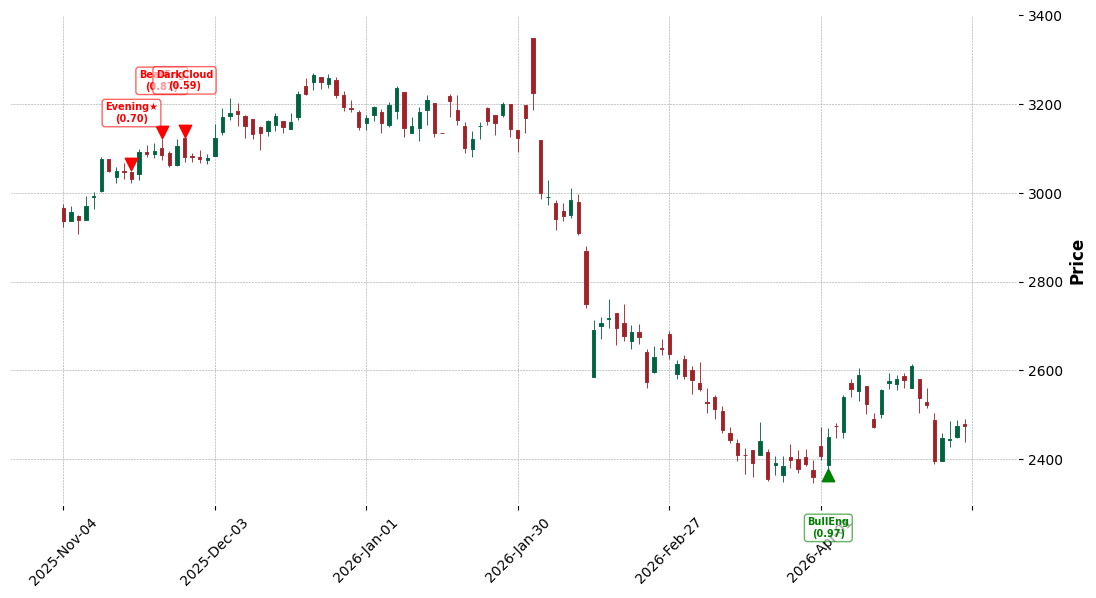

In [71]:
lot = 0
lot_size = 200
_ = analysis(lot, lot_size, claude=1, conf_threshold=0.2)

In [64]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import os
print(os.getcwd())


def generate_pdf(num_lots):
    with PdfPages("report.pdf") as pdf:
        for lot in range(num_lots):
            fig = analysis(lot, lot_size, claude=1, conf_threshold=0.5)   # your function returns mplfinance fig
            
            if fig is None:
                continue

            pdf.savefig(fig)   # add page
            fig.clf()          # clear memory (important for loops)
            plt.close(fig)


num_lots = 10
generate_pdf(num_lots)

c:\Users\Tathagata\Desktop\Code\BruteQuantLabs\analysis_scripts
